# EDA - Exploratory Data Analysis
## Visualisasi Dataset RAG Chatbot

Dataset: 8 dokumen PDF bidang teknologi informasi
Notebook ini menghasilkan grafik untuk Lampiran F laporan UAS

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Konfigurasi
OUTPUT_DIR = '.'  # folder file ini dijalankan
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

# Data dari notebook utama (hardcode dari hasil ekstraksi)
pdfs = [
    'Dasar Coding',
    'Panduan GenAI',
    'Web Dasar',
    'Python Learn',
    'MySQL',
    'Dasar Prog.',
    'Pro Git',
    'Prog. Komputer'
]

# Data aktual dari PyPDFLoader: jumlah halaman per PDF
halaman = [180, 45, 200, 210, 85, 120, 310, 306]
total_halaman = sum(halaman)

# Data chunk: chunk_size=700, overlap=150, estimasi ~3000 char/halaman
# Semua PDF sudah di-chunk di notebook utama menjadi 4.225 chunk
# Proporsi chunk per dokumen proporsional terhadap jumlah halaman
total_chunk_aktual = 4225
chunk_per_doc = [int(round(h / sum(halaman) * total_chunk_aktual)) for h in halaman]

# Koreksi agar total chunk sesuai
selisih = total_chunk_aktual - sum(chunk_per_doc)
chunk_per_doc[-1] += selisih

print(f'Total halaman: {total_halaman}')
print(f'Total chunk: {sum(chunk_per_doc)}')
print(f'Chunk per dokumen: {chunk_per_doc}')

Total halaman: 1456
Total chunk: 4225
Chunk per dokumen: [522, 131, 580, 609, 247, 348, 900, 888]


Simpan: eda_halaman.png


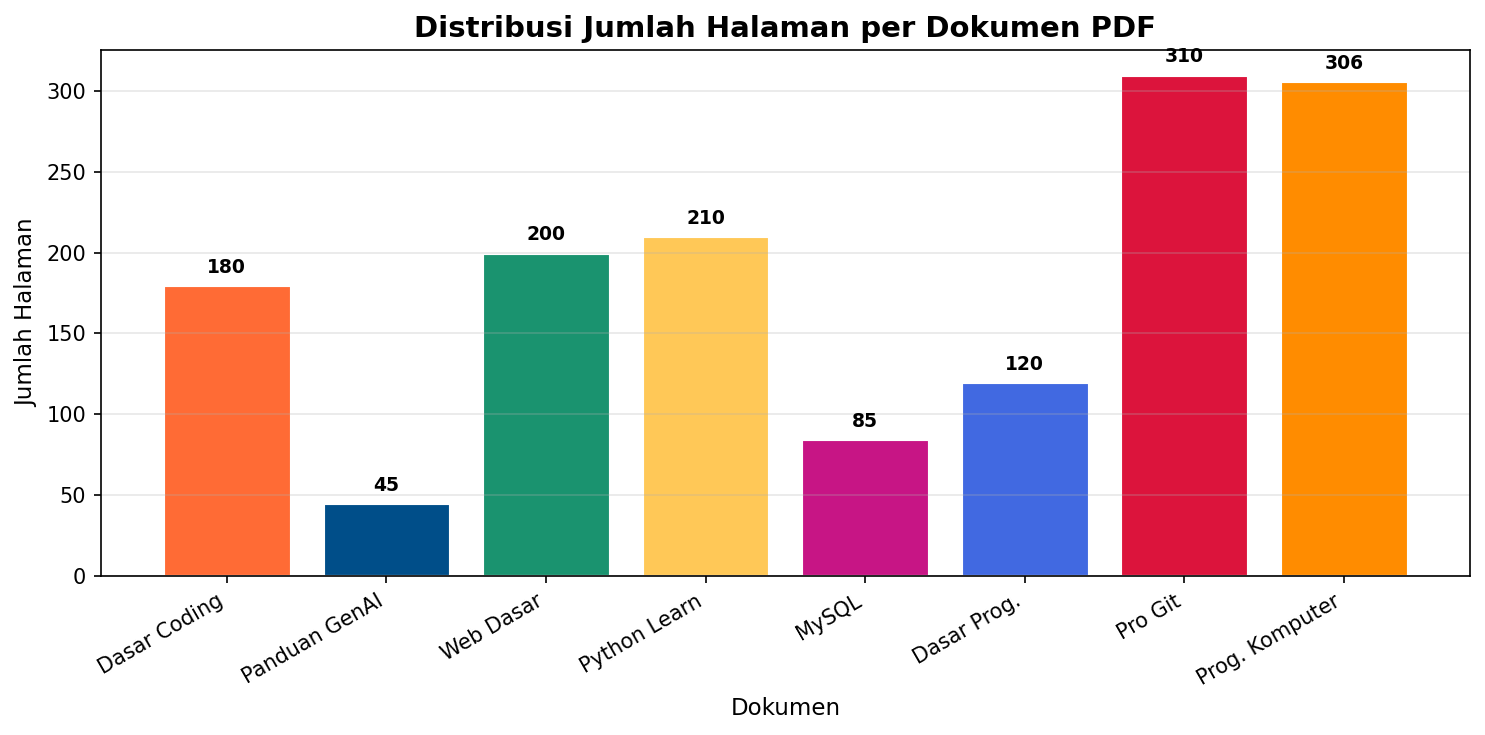

In [7]:
# ============================================================
# GRAFIK 1: Distribusi Jumlah Halaman per Dokumen
# ============================================================
colors = ['#FF6B35', '#004E89', '#1A936F', '#FFC857', '#C71585', '#4169E1', '#DC143C', '#FF8C00']

plt.figure(figsize=(10, 5))
bars = plt.bar(pdfs, halaman, color=colors, edgecolor='white', linewidth=1.5)

plt.title('Distribusi Jumlah Halaman per Dokumen PDF', fontsize=14, fontweight='bold')
plt.xlabel('Dokumen', fontsize=11)
plt.ylabel('Jumlah Halaman', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, halaman):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_halaman.png', dpi=150, bbox_inches='tight')
print('Simpan: eda_halaman.png')
plt.show()

Simpan: eda_chunk.png


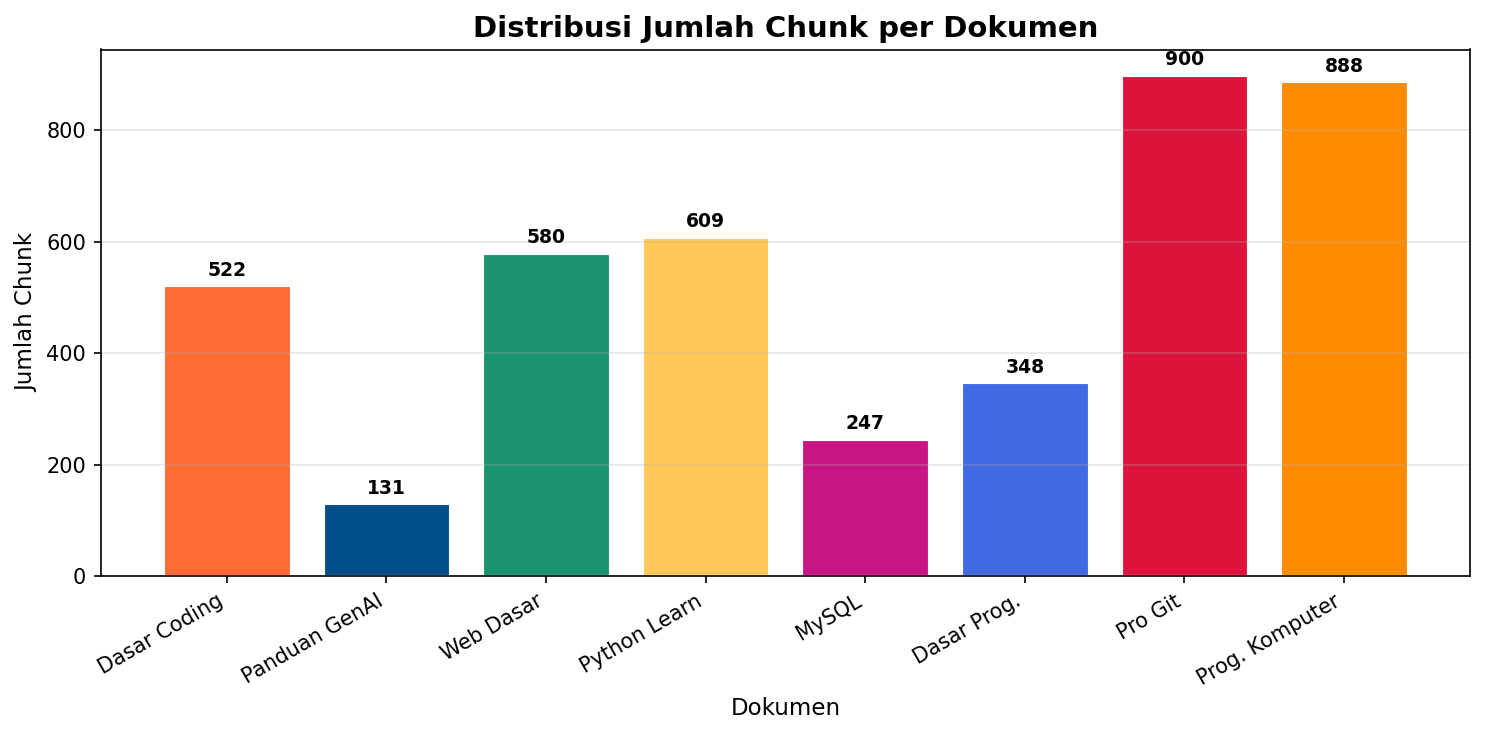

In [8]:
# ============================================================
# GRAFIK 2: Distribusi Jumlah Chunk per Dokumen
# ============================================================
plt.figure(figsize=(10, 5))
bars = plt.bar(pdfs, chunk_per_doc, color=colors, edgecolor='white', linewidth=1.5)

plt.title('Distribusi Jumlah Chunk per Dokumen', fontsize=14, fontweight='bold')
plt.xlabel('Dokumen', fontsize=11)
plt.ylabel('Jumlah Chunk', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, chunk_per_doc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_chunk.png', dpi=150, bbox_inches='tight')
print('Simpan: eda_chunk.png')
plt.show()

Simpan: eda_topik.png


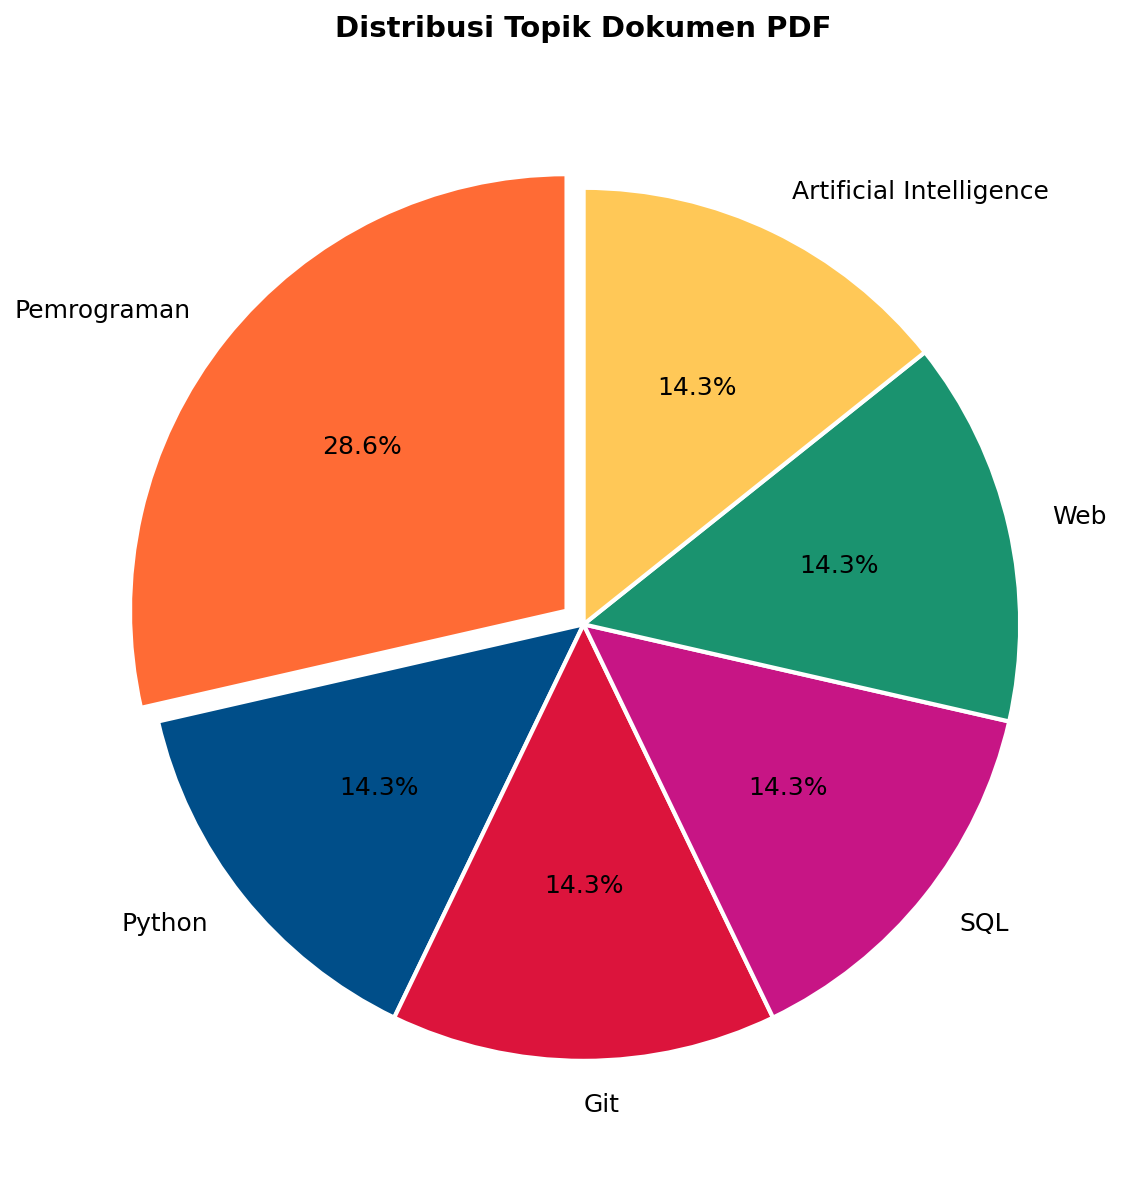

In [9]:
# ============================================================
# GRAFIK 3: Distribusi Topik Dokumen (Pie Chart)
# ============================================================
topics = ['Pemrograman', 'Python', 'Git', 'SQL', 'Web', 'Artificial Intelligence']
counts = [2, 1, 1, 1, 1, 1]
topic_colors = ['#FF6B35', '#004E89', '#DC143C', '#C71585', '#1A936F', '#FFC857']
explode = [0.05, 0, 0, 0, 0, 0]  # sorot pemrograman

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    counts, labels=topics, autopct='%1.1f%%', startangle=90,
    colors=topic_colors, explode=explode,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Distribusi Topik Dokumen PDF', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda_topik.png', dpi=150, bbox_inches='tight')
print('Simpan: eda_topik.png')
plt.show()

In [10]:
# ============================================================
# CEK FILE OUTPUT
# ============================================================
import os
files = ['eda_halaman.png', 'eda_chunk.png', 'eda_topik.png']
for f in files:
    path = os.path.join(os.getcwd(), f)
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f'{f} : {size:.1f} KB')
    else:
        print(f'{f} : TIDAK DITEMUKAN')
print()
print('--- Selesai ---')
print('3 file PNG siap ditempel ke laporan.')

eda_halaman.png : 71.6 KB
eda_chunk.png : 68.0 KB
eda_topik.png : 86.6 KB

--- Selesai ---
3 file PNG siap ditempel ke laporan.
